# DINOv3 zoom — layer by layer

Same detector as `03_dinov3_detect.ipynb`, but `run_zoom_detector(..., trace=levels)`
records every DINO view of the coarse-to-fine recursion. Each layer is rendered as
an image:

1. the input crop fed to DINO,
2. its anomaly heatmap,
3. its thresholded mask with region centers, inscribed radii and child zoom zones,
4. the raw points emitted by that layer (pre-merge).

Runtime note: with `resolution_scale=4.0` the full-frame pass is tiled and every
zoom crop is re-fed at the same relative resolution; expect minutes on a 4090.

Zoom context: `merge_gap=0.08` fuses zones closer than 8% of the current view's
long side and `min_zone_fraction=0.25` grows every crop to at least 25% of it, so
each layer sees several nearby detections with surrounding context instead of an
isolated pinpoint.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch

from fish_segmentation.dinov3 import (
    ZOOM_LEVEL_COLORS,
    load_backbone,
    plot_zoom_level,
    plot_zoom_overview,
    remove_letterbox,
    run_zoom_detector,
)
from fish_segmentation.paths import find_repo_root, load_env
from fish_segmentation.video_io import load_sampled_frames

load_env()
ROOT = find_repo_root()

device = "cuda" if torch.cuda.is_available() else "cpu"
DINO_LONG_SIDE = 1024
DINO_RESOLUTION_SCALE = 4.0
ZONE_MERGE_GAP = 0.08       # fuse zones closer than 8% of the view's long side
MIN_ZONE_FRACTION = 0.25    # each zoom crop covers >= 25% of the long side
print(device)

cuda


In [2]:
model_id = "facebook/dinov3-vitl16-pretrain-lvd1689m"
model, processor = load_backbone(model_id, device=device)

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

In [3]:
video_path = ROOT / "dataset" / "processed" / "20260813_213529_7f994a2f" / "video.mp4"
if not video_path.exists():
    video_path = ROOT / "data" / "test_media" / "dolphin_00.mp4"
print(f"Using video: {video_path}")
frames = load_sampled_frames(video_path=str(video_path), n_frames=3)
frame = frames[len(frames) // 2]
print(f"Diagnostic frame: {frame.size[0]}x{frame.size[1]}")

Using video: /workspace/fish-segmentation/dataset/processed/20260813_213529_7f994a2f/video.mp4


Diagnostic frame: 3840x2160


In [4]:
# trace=levels collects one record per DINO view in recursion order:
# depth, origin, size, scale, feed_native, norm_score, mask, regions, zones, points.
levels = []
detections = run_zoom_detector(
    image=frame,
    model=model,
    processor=processor,
    long_side=DINO_LONG_SIDE,
    resolution_scale=DINO_RESOLUTION_SCALE,
    merge_gap=ZONE_MERGE_GAP,
    min_zone_fraction=MIN_ZONE_FRACTION,
    trace=levels,
)

cropped_frame = remove_letterbox(frame)
views_per_depth = {}
for entry in levels:
    views_per_depth[entry["depth"]] = views_per_depth.get(entry["depth"], 0) + 1
print(f"{len(levels)} DINO views: {dict(sorted(views_per_depth.items()))}")
print(f"{len(detections)} merged detections")

2 DINO views: {0: 1, 1: 1}
5 merged detections


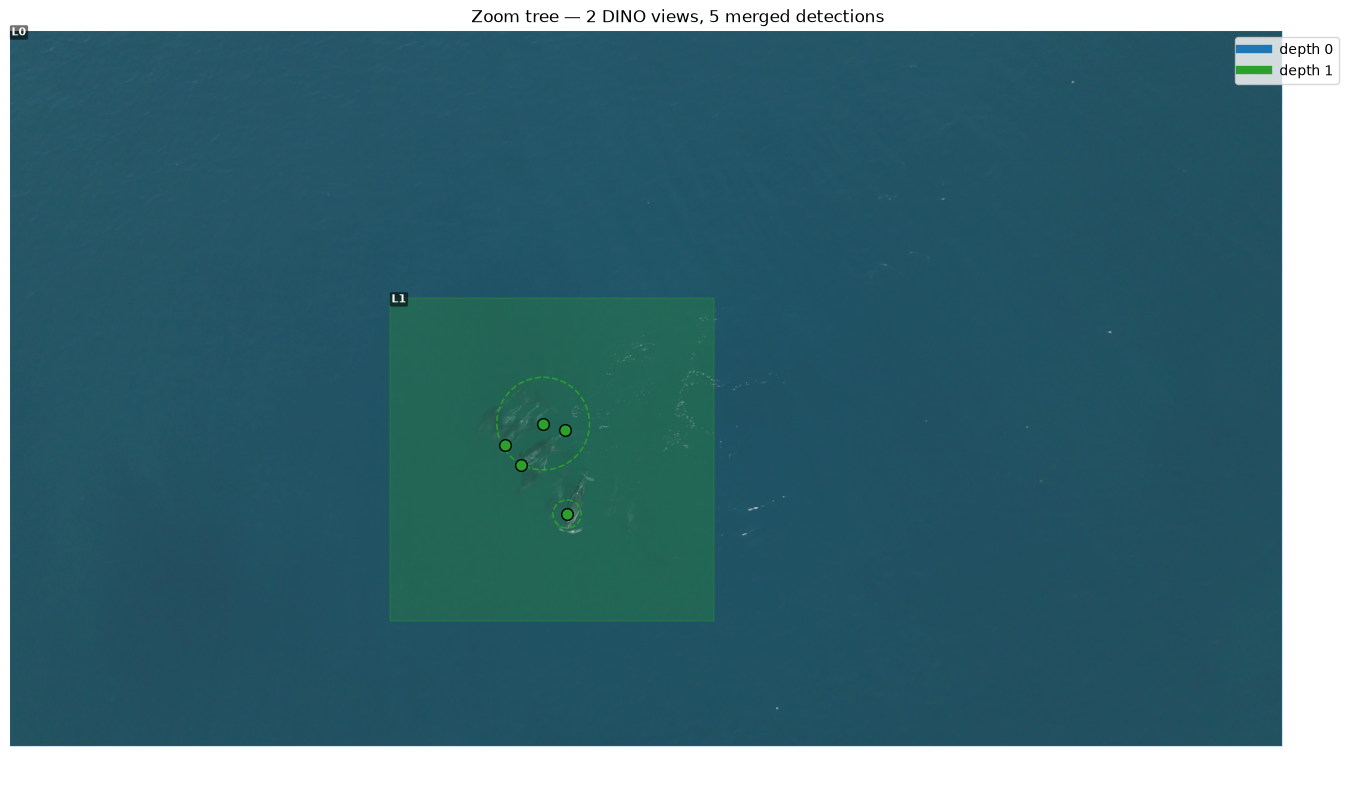

In [5]:
# whole zoom tree on one image: one box per view, colored by recursion depth
plot_zoom_overview(cropped_frame, levels, detections)

## Layer by layer

Each figure below is one DINO view of the recursion (depth-first order), with four
panels:

1. **layer input** — the crop fed to DINO,
2. **anomaly heatmap** — the raw normalized `norm_score` before thresholding,
3. **mask + regions + zones** — thresholded mask with region interior points
   (cyan, dashed = max inscribed radius) and the child zoom boxes,
4. **points emitted** — the raw pre-merge detections produced by this layer.

The final merged points (after `_merge_points`) are shown in the overview above.

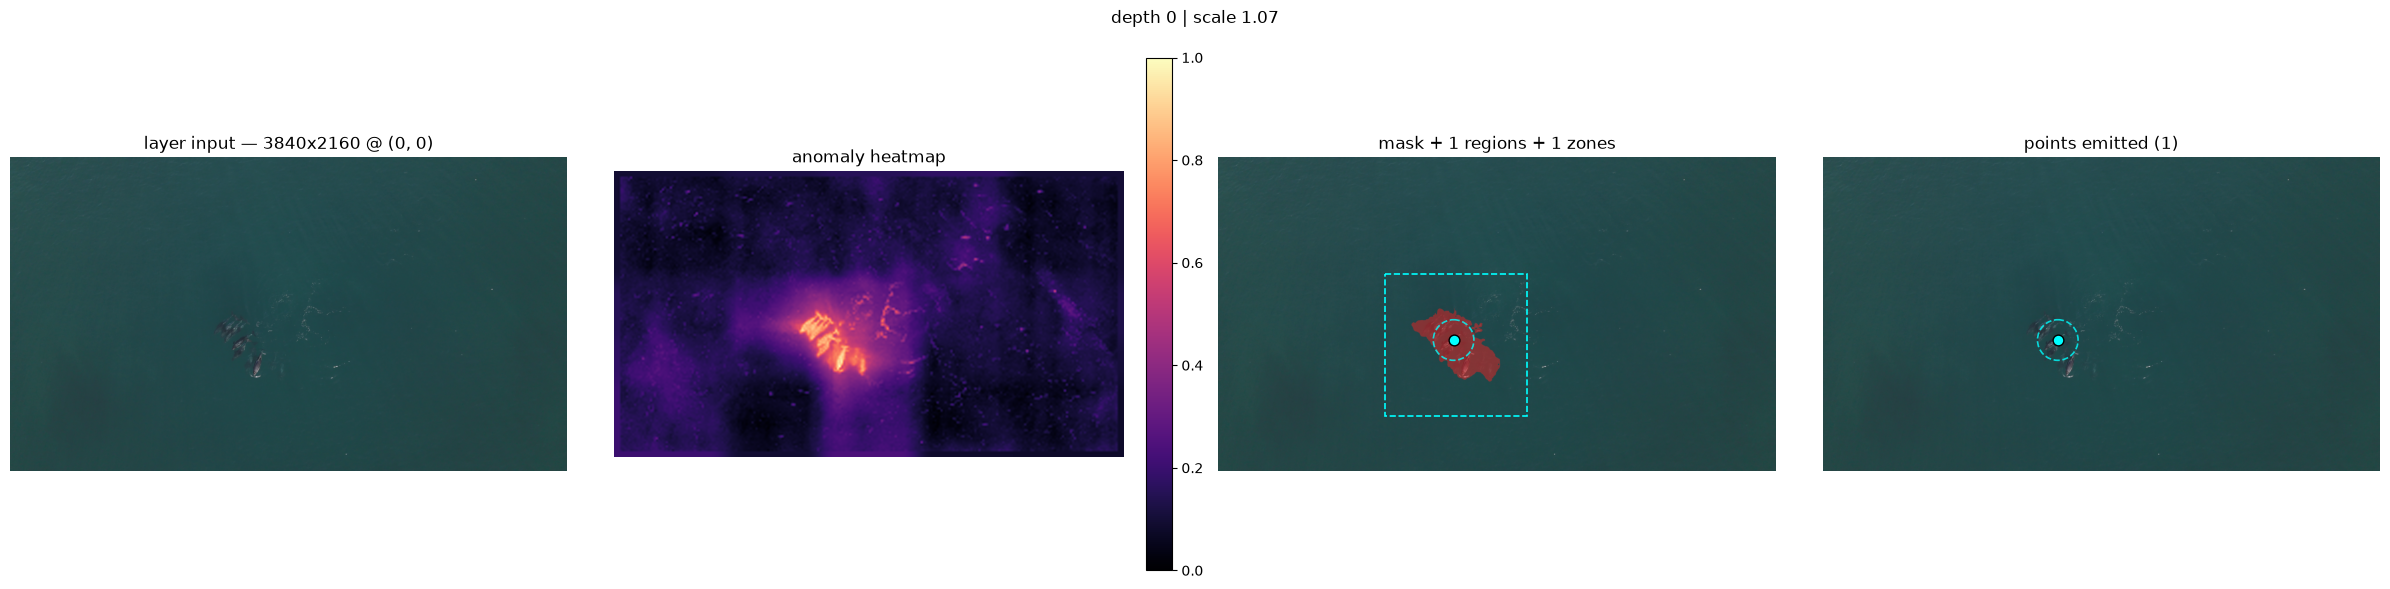

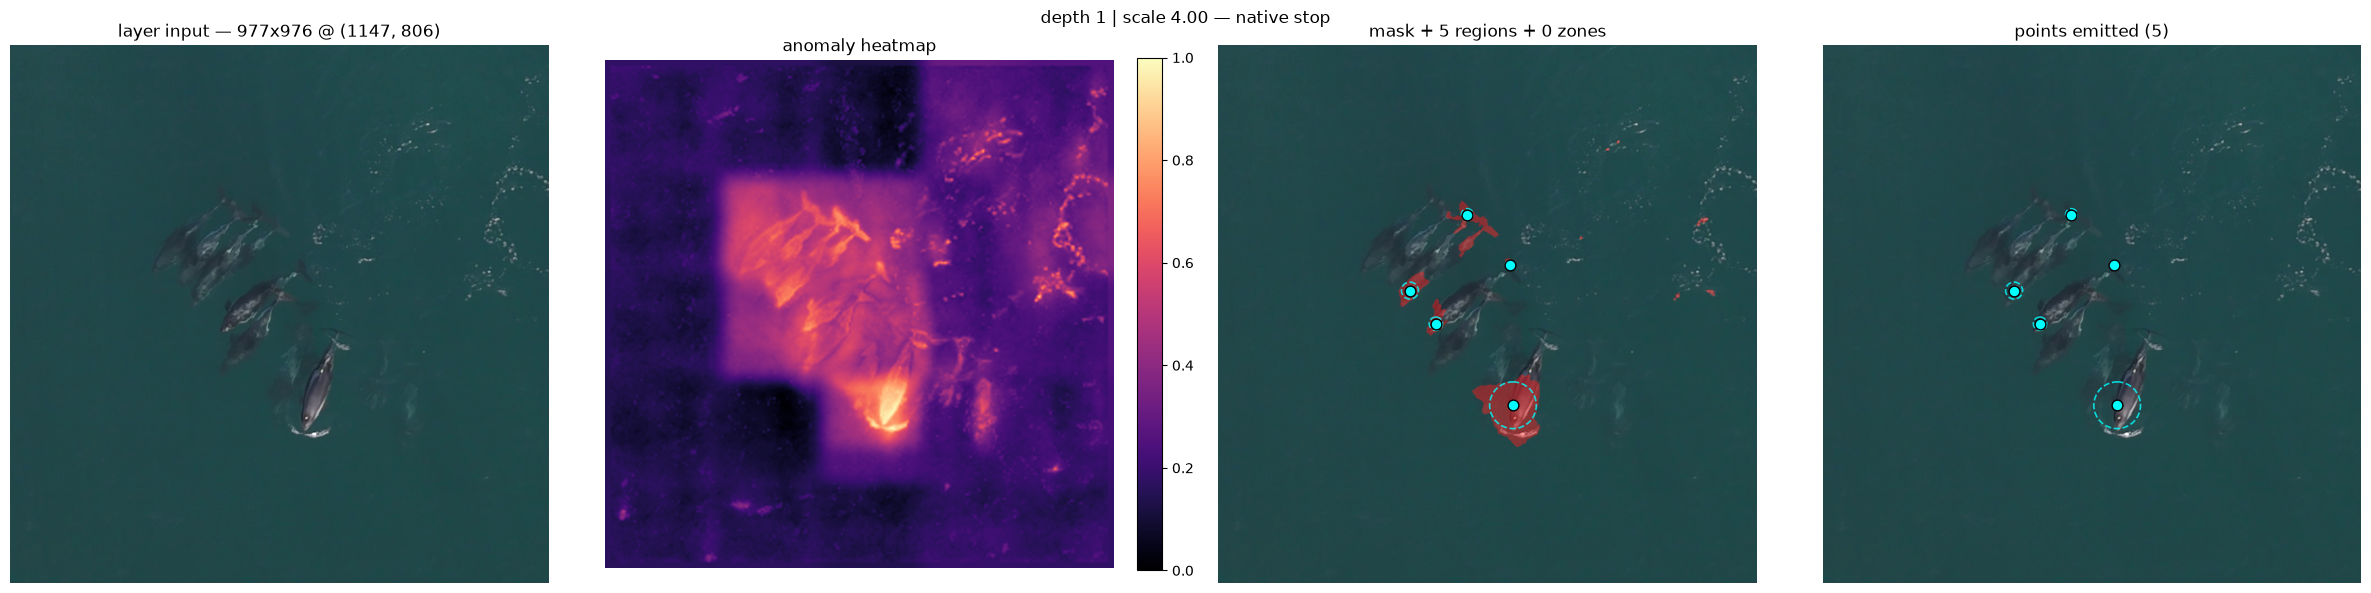

In [6]:
for entry in levels:
    plot_zoom_level(cropped_frame, entry)

## Final merged detections

Raw per-layer points are deduplicated by `_merge_points`; each surviving point keeps
the deepest level it was confirmed at.

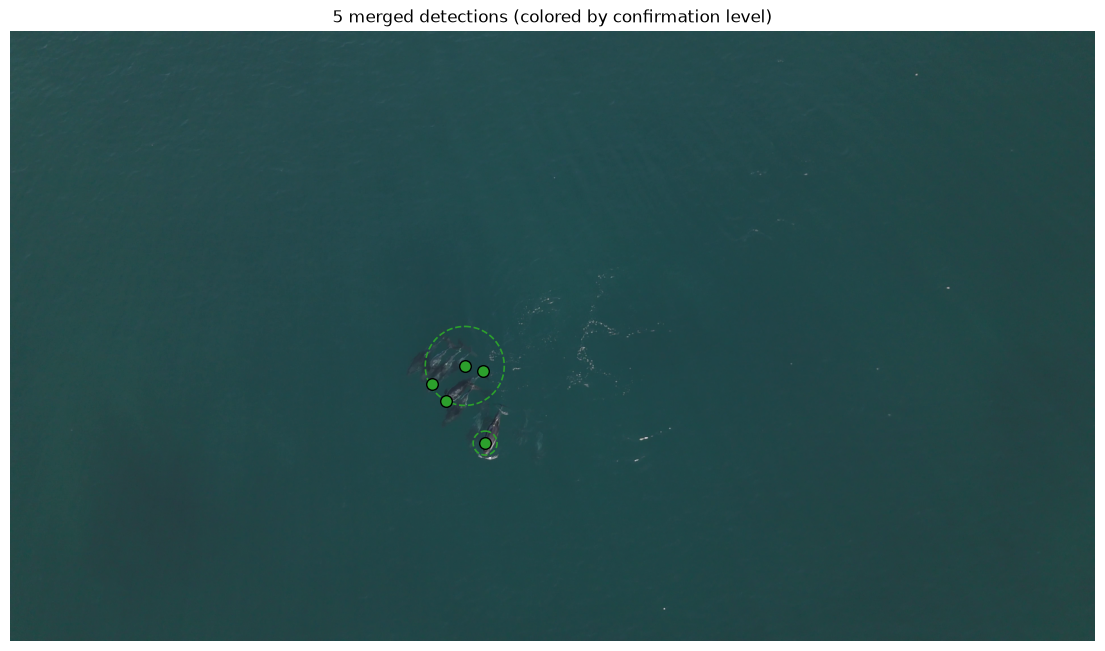

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8))
ax.imshow(cropped_frame)
W, H = cropped_frame.size
for det in detections:
    cx, cy, r = det["x"] * W, det["y"] * H, det["radius"] * max(W, H)
    color = ZOOM_LEVEL_COLORS[det["level"] % len(ZOOM_LEVEL_COLORS)]
    ax.scatter(cx, cy, c=color, edgecolors="black", s=70, zorder=5)
    ax.add_patch(plt.Circle((cx, cy), r, color=color, fill=False, linestyle="--", linewidth=1.2))
ax.set_title(f"{len(detections)} merged detections (colored by confirmation level)")
ax.axis("off")
plt.show()